📊 Suggested Flow for You

Step 1: Run Logistic Regression & Naive Bayes (baseline).

Step 2: Hyperparameter tuning (GridSearchCV or RandomizedSearchCV).

Step 3: Train Random Forest / XGBoost (more complex classical ML).

Step 4: Train BiLSTM on Word2Vec/GloVe.

Step 5: Error analysis (wrong predictions, confusion matrix per label).

Step 6: Summarize results in a comparison table.

### Importing important Libraries

In [ ]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
from sklearn.metrics import RocCurveDisplay, roc_curve, auc

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from IPython.display import display

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#read dataset
Dataset = pd.read_csv('/content/drive/MyDrive/TCC/train.csv')

In [ ]:
X_train = pd.read_csv('/content/drive/MyDrive/TCC/train_features.csv')
X_test = pd.read_csv('/content/drive/MyDrive/TCC/test_features.csv')

In [ ]:
X_train.columns

Index(['comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult',
       'identity_hate', 'any_label', 'preprocessed_text', 'sentence_count',
       'word_counts', 'unique_word_count', 'avg_word_len',
       'uppercase_char_count', 'uppercase_word_counts', 'hashtags_count',
       'mentions_count', 'asterisk_count', 'digits_count', 'stopword_count',
       'TextBlob_Subjectivity', 'TextBlob_Polarity', 'TextBlob_Analysis',
       'toxic_words_count', 'severe_toxic_count', 'obscene_words_count',
       'threat_words_count', 'insult_words_count',
       'identity_hate_words_count'],
      dtype='object')

In [ ]:
cols = ['sentence_count',
       'word_counts', 'unique_word_count', 'avg_word_len',
       'uppercase_char_count', 'uppercase_word_counts', 'hashtags_count',
       'mentions_count', 'asterisk_count', 'digits_count', 'stopword_count',
       'TextBlob_Subjectivity', 'TextBlob_Polarity', 'TextBlob_Analysis',
       'toxic_words_count', 'severe_toxic_count', 'obscene_words_count',
       'threat_words_count', 'insult_words_count',
       'identity_hate_words_count']

In [ ]:
train_features = X_train[cols].copy()
test_features = X_test[cols].copy()

In [ ]:
print('Train features shape:', train_features.shape)
print('Test features shape:', test_features.shape)

Train features shape: (127656, 20)
Test features shape: (31915, 20)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_features)
X_test_scaled = scaler.transform(test_features)

In [ ]:
labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

In [ ]:
y_train = X_train[labels]
y_test = X_test[labels]

In [ ]:
print('Y_train shape:', y_train.shape)
print('Y_test shape:', y_test.shape)

Y_train shape: (127656, 6)
Y_test shape: (31915, 6)


In [ ]:
from scipy import sparse
X_train_tfidf = sparse.load_npz("/content/drive/MyDrive/TCC/X_train_tfidf.npz")
X_test_tfidf  = sparse.load_npz("/content/drive/MyDrive/TCC/X_test_tfidf.npz")

In [ ]:
print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Train TF-IDF shape: (127656, 5000)
Test TF-IDF shape: (31915, 5000)


In [ ]:
X_train_word2vec = np.load('/content/drive/MyDrive/TCC/X_train_w2v.npy')
X_test_word2vec  = np.load('/content/drive/MyDrive/TCC/X_test_w2v.npy')

In [ ]:
print('Train word2vec shape:', X_train_word2vec.shape)
print('Test word2vec shape:', X_test_word2vec.shape)

Train word2vec shape: (127656, 100)
Test word2vec shape: (31915, 100)


In [ ]:
X_train_glove = np.load('/content/drive/MyDrive/TCC/X_train_glove.npy')
X_test_glove  = np.load('/content/drive/MyDrive/TCC/X_test_glove.npy')

In [ ]:
print('Train glove shape:', X_train_glove.shape)
print('Test glove shape:', X_test_glove.shape)

Train glove shape: (127656, 100)
Test glove shape: (31915, 100)


Lets Check out the correlation between labels

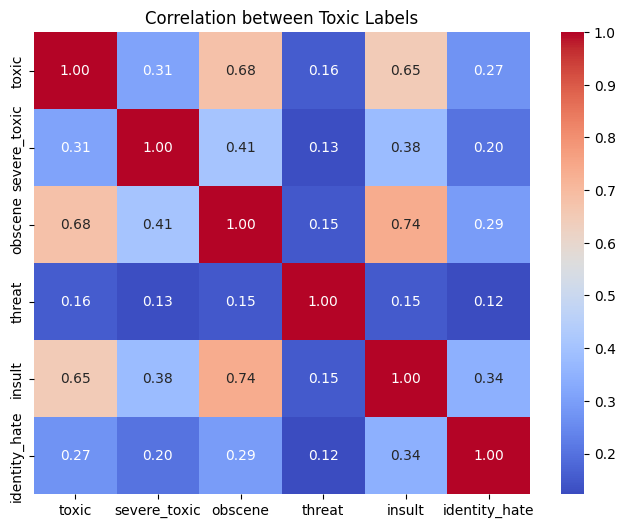

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# y_train ya Dataset[labels] use karo
corr = X_train[labels].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between Toxic Labels")
plt.show()


# Baseline Models

# Evaluation Metircs Function

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(y_true, y_pred, y_proba, labels):
    results = {}

    # ensure numpy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_proba = np.array(y_proba)

    # --- Global metrics (multi-label aware) ---
    for avg in ["micro", "macro"]:
        results[f'precision_{avg}'] = precision_score(y_true, y_pred, average=avg, zero_division=0)
        results[f'recall_{avg}']    = recall_score(y_true, y_pred, average=avg, zero_division=0)
        results[f'f1_{avg}']        = f1_score(y_true, y_pred, average=avg, zero_division=0)

    # ROC-AUC (macro only makes sense)
    results['roc_auc_macro'] = roc_auc_score(y_true, y_proba, average="macro")

    print("\n--- Global Metrics ---")
    for k,v in results.items():
        print(f"{k}: {v:.4f}")

    # --- Per-label metrics ---
    rows = []
    for i, label in enumerate(labels):
        prec = precision_score(y_true[:, i], y_pred[:, i], zero_division=0)
        rec  = recall_score(y_true[:, i], y_pred[:, i], zero_division=0)
        f1   = f1_score(y_true[:, i], y_pred[:, i], zero_division=0)
        auc  = roc_auc_score(y_true[:, i], y_proba[:, i]) if len(set(y_true[:, i])) > 1 else None
        rows.append([label, prec, rec, f1, auc])

    per_label_df = pd.DataFrame(rows, columns=["Label","Precision","Recall","F1","ROC-AUC"])
    print("\n--- Per-label Metrics ---")
    display(per_label_df)

    return results, per_label_df


## Logistic Regression on TFDIF

We begin with Logistic Regression on TF-IDF features as our baseline model because this combination is a well-established standard in text classification tasks. Logistic Regression is simple, interpretable, and computationally efficient, making it an ideal starting point for large, high-dimensional datasets such as this one.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_auc_score, roc_curve

lr = LogisticRegression(random_state = 42)
ovr_lr = OneVsRestClassifier(lr)

In [ ]:
print("Training Logistic Regression (TF-IDF)...")
ovr_lr.fit(X_train_tfidf, y_train)

# Predictions
y_pred = ovr_lr.predict(X_test_tfidf)
y_pred_proba = ovr_lr.predict_proba(X_test_tfidf)

Training Logistic Regression (TF-IDF)...


In [ ]:
print('Evaluation of Logistic Regression model')
evaluate_model(y_test, y_pred, y_pred_proba, labels)

Evaluation of Logistic Regression model

--- Global Metrics ---
precision_micro: 0.8605
recall_micro: 0.5700
f1_micro: 0.6857
precision_macro: 0.7473
recall_macro: 0.3995
f1_macro: 0.5008
roc_auc_macro: 0.9720

--- Per-label Metrics ---


,Label,Precision,Recall,F1,ROC-AUC
0,toxic,0.896635,0.612278,0.727663,0.961432
1,severe_toxic,0.528571,0.242623,0.332584,0.980312
2,obscene,0.897415,0.647413,0.752185,0.975939
3,threat,0.625000,0.102041,0.175439,0.974894
4,insult,0.806660,0.553299,0.656379,0.972065
5,identity_hate,0.729412,0.239382,0.360465,0.967470


({'precision_micro': 0.8604651162790697,
  'recall_micro': 0.5699683270947308,
  'f1_micro': 0.6857192344331862,
  'precision_macro': 0.7472821367154672,
  'recall_macro': 0.3995061087548529,
  'f1_macro': 0.5007858005949434,
  'roc_auc_macro': np.float64(0.9720186801871685)},
            Label  Precision    Recall        F1   ROC-AUC
 0          toxic   0.896635  0.612278  0.727663  0.961432
 1   severe_toxic   0.528571  0.242623  0.332584  0.980312
 2        obscene   0.897415  0.647413  0.752185  0.975939
 3         threat   0.625000  0.102041  0.175439  0.974894
 4         insult   0.806660  0.553299  0.656379  0.972065
 5  identity_hate   0.729412  0.239382  0.360465  0.967470)

## Naive Bayes - Multinomial NB on TFIDF

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
ovr_nb = OneVsRestClassifier(nb)

In [ ]:
print("Training Naive Bayes (TF-IDF)...")
ovr_nb.fit(X_train_tfidf, y_train)

# Predictions
y_pred = ovr_nb.predict(X_test_tfidf)
y_pred_proba = ovr_nb.predict_proba(X_test_tfidf)

Training Naive Bayes (TF-IDF)...


In [ ]:
print('Evaluation of Naive Bayes model')
evaluate_model(y_test, y_pred, y_pred_proba, labels)

Evaluation of Naive Bayes model

--- Global Metrics ---
precision_micro: 0.8646
recall_micro: 0.4752
f1_micro: 0.6133
precision_macro: 0.6381
recall_macro: 0.3168
f1_macro: 0.4111
roc_auc_macro: 0.9575

--- Per-label Metrics ---


,Label,Precision,Recall,F1,ROC-AUC
0,toxic,0.922527,0.508207,0.655377,0.950906
1,severe_toxic,0.515723,0.268852,0.353448,0.972389
2,obscene,0.891839,0.545728,0.677118,0.962602
3,threat,0.166667,0.010204,0.019231,0.947103
4,insult,0.811674,0.467640,0.593398,0.962374
5,identity_hate,0.520000,0.100386,0.168285,0.949718


({'precision_micro': 0.8645887899423782,
  'recall_micro': 0.4752375467895191,
  'f1_micro': 0.6133407655146785,
  'precision_macro': 0.6380715841589669,
  'recall_macro': 0.3168362931130208,
  'f1_macro': 0.4111427845608911,
  'roc_auc_macro': np.float64(0.9575153596277648)},
            Label  Precision    Recall        F1   ROC-AUC
 0          toxic   0.922527  0.508207  0.655377  0.950906
 1   severe_toxic   0.515723  0.268852  0.353448  0.972389
 2        obscene   0.891839  0.545728  0.677118  0.962602
 3         threat   0.166667  0.010204  0.019231  0.947103
 4         insult   0.811674  0.467640  0.593398  0.962374
 5  identity_hate   0.520000  0.100386  0.168285  0.949718)

### Best out of two

The comparison shows that Logistic Regression consistently outperforms Naive Bayes across most evaluation metrics. While both achieve similar precision, Logistic Regression provides significantly better recall, F1-scores, and ROC-AUC, indicating stronger overall performance. It is especially effective on frequent labels (toxic, obscene, insult) and shows clear improvements on rare labels like threat and identity_hate. Naive Bayes only slightly outperforms Logistic Regression on severe_toxic, but the difference is minimal. Overall, Logistic Regression emerges as a more reliable baseline for this multi-label toxic comment classification task.

# Complex Models

### Linear models - LR, SVm

### Logistic regressioon on handcrafted features

In [ ]:
lr = LogisticRegression(random_state = 42)
ovr_lr = OneVsRestClassifier(lr)

In [ ]:
X_train_scaled

array([[-2.97254526e-01, -4.76491409e-01, -6.43329656e-01, ...,
        -9.47695094e-01, -9.05092625e-01, -8.96774111e-01],
       [ 7.55480932e-03, -2.01583350e-02,  4.55485864e-04, ...,
        -9.47695094e-01, -9.05092625e-01, -8.96774111e-01],
       [-5.00460750e-01, -5.11593953e-01, -5.84803734e-01, ...,
         2.34710052e-01,  3.17170193e-01,  4.68553163e-01],
       ...,
       [-5.00460750e-01, -5.81799042e-01, -7.01855577e-01, ...,
        -9.47695094e-01, -9.05092625e-01, -8.96774111e-01],
       [ 5.15570369e-01,  6.99443820e-01,  8.49081354e-01, ...,
         1.41711520e+00,  1.53943301e+00,  1.83388044e+00],
       [-2.97254526e-01, -4.94042681e-01, -5.84803734e-01, ...,
         2.34710052e-01,  3.17170193e-01,  4.68553163e-01]])

In [ ]:
print("Training Logistic Regression (Handcrafted features)...")
ovr_lr.fit(X_train_scaled, y_train)

# Predictions
y_pred = ovr_lr.predict(X_test_scaled)
y_pred_proba = ovr_lr.predict_proba(X_test_scaled)

Training Logistic Regression (Handcrafted features)...


In [ ]:
print('Evaluation of Logistic Regression model')
evaluate_model(y_test, y_pred, y_pred_proba, labels)

Evaluation of Logistic Regression model

--- Global Metrics ---
precision_micro: 0.7554
recall_micro: 0.2280
f1_micro: 0.3503
precision_macro: 0.6485
recall_macro: 0.1603
f1_macro: 0.2477
roc_auc_macro: 0.8470

--- Per-label Metrics ---


,Label,Precision,Recall,F1,ROC-AUC
0,toxic,0.764338,0.240643,0.366042,0.799711
1,severe_toxic,0.436893,0.147541,0.220588,0.907994
2,obscene,0.800712,0.270758,0.404676,0.850524
3,threat,0.666667,0.020408,0.039604,0.847343
4,insult,0.783217,0.213198,0.335162,0.842030
5,identity_hate,0.439024,0.069498,0.120000,0.834667


({'precision_micro': 0.7553648068669528,
  'recall_micro': 0.2280449179383818,
  'f1_micro': 0.3503262191750525,
  'precision_macro': 0.648475106618697,
  'recall_macro': 0.1603411292497537,
  'f1_macro': 0.24767883273122973,
  'roc_auc_macro': np.float64(0.8470448239402097)},
            Label  Precision    Recall        F1   ROC-AUC
 0          toxic   0.764338  0.240643  0.366042  0.799711
 1   severe_toxic   0.436893  0.147541  0.220588  0.907994
 2        obscene   0.800712  0.270758  0.404676  0.850524
 3         threat   0.666667  0.020408  0.039604  0.847343
 4         insult   0.783217  0.213198  0.335162  0.842030
 5  identity_hate   0.439024  0.069498  0.120000  0.834667)

Logistic Regression on handcrafted features gives high precision but very low recall. This means the model is good at predicting correctly when it says a comment is toxic, but it misses many toxic comments. Overall, the performance is weak, especially for rare classes like threat and identity_hate. Handcrafted features alone are not enough, so they should be combined with stronger text features like TF-IDF.

### Tree models - RF, DT

### Random Forest on handcrafted features

In [ ]:
rfc = RandomForestClassifier(random_state = 42)
ovr_rfc = OneVsRestClassifier(rfc)

In [ ]:
print("Training Random forest (Handcrafted features)...")
ovr_rfc.fit(train_features, y_train)

# Predictions
y_pred = ovr_rfc.predict(test_features)
y_pred_proba = ovr_rfc.predict_proba(test_features)

Training Random forest (Handcrafted features)...


In [ ]:
print('Evaluation of Random forest (Handcrafted features)')
evaluate_model(y_test, y_pred, y_pred_proba, labels)

Evaluation of Random forest (Handcrafted features)

--- Global Metrics ---
precision_micro: 0.7658
recall_micro: 0.3671
f1_micro: 0.4963
precision_macro: 0.6723
recall_macro: 0.2357
f1_macro: 0.3230
roc_auc_macro: 0.8755

--- Per-label Metrics ---


,Label,Precision,Recall,F1,ROC-AUC
0,toxic,0.790396,0.399869,0.531066,0.859350
1,severe_toxic,0.500000,0.163934,0.246914,0.940175
2,obscene,0.797606,0.441035,0.567997,0.900024
3,threat,0.750000,0.030612,0.058824,0.802007
4,insult,0.719463,0.340102,0.461870,0.887362
5,identity_hate,0.476190,0.038610,0.071429,0.864123


({'precision_micro': 0.7657657657657657,
  'recall_micro': 0.367117765620501,
  'f1_micro': 0.49630206305955626,
  'precision_macro': 0.6722759173119116,
  'recall_macro': 0.23569363508835317,
  'f1_macro': 0.3230164202383642,
  'roc_auc_macro': np.float64(0.8755067237623266)},
            Label  Precision    Recall        F1   ROC-AUC
 0          toxic   0.790396  0.399869  0.531066  0.859350
 1   severe_toxic   0.500000  0.163934  0.246914  0.940175
 2        obscene   0.797606  0.441035  0.567997  0.900024
 3         threat   0.750000  0.030612  0.058824  0.802007
 4         insult   0.719463  0.340102  0.461870  0.887362
 5  identity_hate   0.476190  0.038610  0.071429  0.864123)

Random Forest on handcrafted features performs better than Logistic Regression on the same features, with higher F1-scores for common labels. However, recall remains very low, especially for rare classes (threat, identity_hate), which the model nearly ignores. This confirms that while Random Forest can capture interactions among handcrafted features, imbalance severely limits its effectiveness.

### Decision Trees

In [ ]:
from sklearn import tree

dtc = tree.DecisionTreeClassifier(random_state=42)
ovr_dtc = OneVsRestClassifier(dtc)

In [ ]:
print("Training Decision Trees (Handcrafted features)...")
ovr_dtc.fit(train_features, y_train)

# Predictions
y_pred = ovr_dtc.predict(test_features)
y_pred_proba = ovr_dtc.predict_proba(test_features)

Training Decision Trees (Handcrafted features)...


In [ ]:
print('Evaluation of Decision Trees (Handcrafted features)')
evaluate_model(y_test, y_pred, y_pred_proba, labels)

Evaluation of Decision Trees (Handcrafted features)

--- Global Metrics ---
precision_micro: 0.3809
recall_micro: 0.4297
f1_micro: 0.4038
precision_macro: 0.2826
recall_macro: 0.3265
f1_macro: 0.3026
roc_auc_macro: 0.6503

--- Per-label Metrics ---


,Label,Precision,Recall,F1,ROC-AUC
0,toxic,0.412114,0.455680,0.432803,0.694070
1,severe_toxic,0.237569,0.281967,0.257871,0.639800
2,obscene,0.426478,0.490373,0.456199,0.726706
3,threat,0.094828,0.112245,0.102804,0.554444
4,insult,0.364269,0.398477,0.380606,0.681687
5,identity_hate,0.160112,0.220077,0.185366,0.605168


({'precision_micro': 0.3808855429373485,
  'recall_micro': 0.4297437374028218,
  'f1_micro': 0.40384225123452616,
  'precision_macro': 0.2825617409891973,
  'recall_macro': 0.32646985213549823,
  'f1_macro': 0.302608205379407,
  'roc_auc_macro': np.float64(0.6503125984276182)},
            Label  Precision    Recall        F1   ROC-AUC
 0          toxic   0.412114  0.455680  0.432803  0.694070
 1   severe_toxic   0.237569  0.281967  0.257871  0.639800
 2        obscene   0.426478  0.490373  0.456199  0.726706
 3         threat   0.094828  0.112245  0.102804  0.554444
 4         insult   0.364269  0.398477  0.380606  0.681687
 5  identity_hate   0.160112  0.220077  0.185366  0.605168)

Decision Tree on handcrafted features gives lower overall performance compared to Random Forest, with micro-F1 dropping from ~0.50 to ~0.40 and ROC-AUC from 0.87 to 0.65. While it shows slightly better recall on rare labels like threat and identity_hate, it is unstable and less reliable overall. Random Forest proves to be the stronger model for handcrafted features.

## Boosting - XGBOOST, lightgbm

### XGBoost on handcrafted features

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42)
ovr_xgb = OneVsRestClassifier(xgb)

In [ ]:
print("Training XGBoost (Handcrafted features)...")
ovr_xgb.fit(train_features, y_train)

# Predictions
y_pred = ovr_xgb.predict(test_features)
y_pred_proba = ovr_xgb.predict_proba(test_features)

Training XGBoost (Handcrafted features)...


In [ ]:
print('Evaluation of XGBoost (Handcrafted features)')
evaluate_model(y_test, y_pred, y_pred_proba, labels)

Evaluation of XGBoost (Handcrafted features)

--- Global Metrics ---
precision_micro: 0.7206
recall_micro: 0.4110
f1_micro: 0.5235
precision_macro: 0.5596
recall_macro: 0.2887
f1_macro: 0.3710
roc_auc_macro: 0.8935

--- Per-label Metrics ---


,Label,Precision,Recall,F1,ROC-AUC
0,toxic,0.775570,0.435653,0.557915,0.878334
1,severe_toxic,0.409326,0.259016,0.317269,0.931236
2,obscene,0.761137,0.483153,0.591093,0.910740
3,threat,0.375000,0.061224,0.105263,0.870401
4,insult,0.671413,0.388959,0.492567,0.901721
5,identity_hate,0.364865,0.104247,0.162162,0.868815


({'precision_micro': 0.720595658758203,
  'recall_micro': 0.4110279297437374,
  'f1_micro': 0.5234690135680234,
  'precision_macro': 0.5595519161860238,
  'recall_macro': 0.2887089203484654,
  'f1_macro': 0.371044910327589,
  'roc_auc_macro': np.float64(0.8935410441513394)},
            Label  Precision    Recall        F1   ROC-AUC
 0          toxic   0.775570  0.435653  0.557915  0.878334
 1   severe_toxic   0.409326  0.259016  0.317269  0.931236
 2        obscene   0.761137  0.483153  0.591093  0.910740
 3         threat   0.375000  0.061224  0.105263  0.870401
 4         insult   0.671413  0.388959  0.492567  0.901721
 5  identity_hate   0.364865  0.104247  0.162162  0.868815)

XGBoost on handcrafted features outperforms both Logistic Regression and Random Forest. It achieves higher F1-scores across all labels, showing its strength in capturing feature interactions. However, recall for rare classes remains low, meaning imbalance handling (class weights, SMOTE, threshold tuning) will still be needed later.

### LightGBM

In [ ]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(random_state=42)
ovr_lgbm = OneVsRestClassifier(lgbm)

In [ ]:
print("Training LightGBM (Handcrafted features)...")
ovr_lgbm.fit(train_features, y_train)

# Predictions
y_pred = ovr_lgbm.predict(test_features)
y_pred_proba = ovr_lgbm.predict_proba(test_features)

Training LightGBM (Handcrafted features)...
[LightGBM] [Info] Number of positive: 12248, number of negative: 115408
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015709 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2312
[LightGBM] [Info] Number of data points in the train set: 127656, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.095945 -> initscore=-2.243111
[LightGBM] [Info] Start training from score -2.243111
[LightGBM] [Info] Number of positive: 1290, number of negative: 126366
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026722 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2312
[LightGBM] [Info] Number of data points in the train set: 127656,

In [ ]:
print('Evaluation of LightGBM (Handcrafted features)')
evaluate_model(y_test, y_pred, y_pred_proba, labels)

Evaluation of LightGBM (Handcrafted features)

--- Global Metrics ---
precision_micro: 0.7355
recall_micro: 0.4051
f1_micro: 0.5225
precision_macro: 0.5345
recall_macro: 0.2853
f1_macro: 0.3687
roc_auc_macro: 0.9001

--- Per-label Metrics ---


,Label,Precision,Recall,F1,ROC-AUC
0,toxic,0.793796,0.428431,0.556503,0.880679
1,severe_toxic,0.422619,0.232787,0.300211,0.945303
2,obscene,0.790210,0.475933,0.594067,0.914441
3,threat,0.066667,0.061224,0.063830,0.853979
4,insult,0.721234,0.385787,0.502687,0.907448
5,identity_hate,0.412500,0.127413,0.194690,0.898925


({'precision_micro': 0.7354939884997387,
  'recall_micro': 0.40512525194356463,
  'f1_micro': 0.5224656516895655,
  'precision_macro': 0.5345041356897801,
  'recall_macro': 0.2852624407702942,
  'f1_macro': 0.3686647616970055,
  'roc_auc_macro': np.float64(0.9001291738070613)},
            Label  Precision    Recall        F1   ROC-AUC
 0          toxic   0.793796  0.428431  0.556503  0.880679
 1   severe_toxic   0.422619  0.232787  0.300211  0.945303
 2        obscene   0.790210  0.475933  0.594067  0.914441
 3         threat   0.066667  0.061224  0.063830  0.853979
 4         insult   0.721234  0.385787  0.502687  0.907448
 5  identity_hate   0.412500  0.127413  0.194690  0.898925)

LightGBM is one of the best boosting models for handcrafted features. It performs on par with XGBoost overall, achieving similar F1-scores and even slightly higher ROC-AUC. LightGBM improves insult and identity_hate, while XGBoost is better for severe_toxic and threat. Both are strong candidates compared to Random Forest and Logistic Regression.

Conclusion after baseline models and complex models

Best baseline model (overall): Logistic Regression with TF-IDF features

Best on handcrafted features: LightGBM

# Embedding Base Models

## Logistic Regression on Word2vec embeddings

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_auc_score, roc_curve

lr = LogisticRegression(random_state = 42)
ovr_lr = OneVsRestClassifier(lr)

In [ ]:
print("Training Logistic Regression on word2vec embedding...")
ovr_lr.fit(X_train_word2vec, y_train)

# Predictions
y_pred = ovr_lr.predict(X_test_word2vec)
y_pred_proba = ovr_lr.predict_proba(X_test_word2vec)

Training Logistic Regression on word2vec embedding...


In [ ]:
print('Evaluation of Logistic Regression on word2vec embedding')
evaluate_model(y_test, y_pred, y_pred_proba, labels)

Evaluation of Logistic Regression on word2vec embedding

--- Global Metrics ---
precision_micro: 0.7599
recall_micro: 0.4578
f1_micro: 0.5714
precision_macro: 0.5683
recall_macro: 0.2981
f1_macro: 0.3804
roc_auc_macro: 0.9553

--- Per-label Metrics ---


,Label,Precision,Recall,F1,ROC-AUC
0,toxic,0.808233,0.528562,0.639143,0.942219
1,severe_toxic,0.420000,0.206557,0.276923,0.970039
2,obscene,0.785321,0.515042,0.622093,0.953666
3,threat,0.333333,0.061224,0.103448,0.961390
4,insult,0.713143,0.395939,0.509180,0.955476
5,identity_hate,0.350000,0.081081,0.131661,0.949062


({'precision_micro': 0.7598566308243727,
  'recall_micro': 0.4578174488914483,
  'f1_micro': 0.5713772347497978,
  'precision_macro': 0.5683383705200883,
  'recall_macro': 0.29806770012318556,
  'f1_macro': 0.3804080435799319,
  'roc_auc_macro': np.float64(0.9553086532354623)},
            Label  Precision    Recall        F1   ROC-AUC
 0          toxic   0.808233  0.528562  0.639143  0.942219
 1   severe_toxic   0.420000  0.206557  0.276923  0.970039
 2        obscene   0.785321  0.515042  0.622093  0.953666
 3         threat   0.333333  0.061224  0.103448  0.961390
 4         insult   0.713143  0.395939  0.509180  0.955476
 5  identity_hate   0.350000  0.081081  0.131661  0.949062)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, roc_auc_score, roc_curve

lr = LogisticRegression(random_state = 42)
ovr_lr = OneVsRestClassifier(lr)

In [ ]:
print("Training Logistic Regression on Glove embedding...")
ovr_lr.fit(X_train_glove, y_train)

# Predictions
y_pred = ovr_lr.predict(X_test_glove)
y_pred_proba = ovr_lr.predict_proba(X_test_glove)

Training Logistic Regression on Glove embedding...


In [ ]:
print('Evaluation of Logistic Regression on Glove embedding')
evaluate_model(y_test, y_pred, y_pred_proba, labels)

Evaluation of Logistic Regression on Glove embedding

--- Global Metrics ---
precision_micro: 0.7252
recall_micro: 0.4012
f1_micro: 0.5166
precision_macro: 0.5444
recall_macro: 0.2589
f1_macro: 0.3403
roc_auc_macro: 0.9456

--- Per-label Metrics ---


,Label,Precision,Recall,F1,ROC-AUC
0,toxic,0.773355,0.459291,0.576313,0.927076
1,severe_toxic,0.419355,0.170492,0.242424,0.962297
2,obscene,0.726096,0.438628,0.546887,0.938907
3,threat,0.272727,0.030612,0.055046,0.960793
4,insult,0.695341,0.369289,0.482387,0.941488
5,identity_hate,0.379310,0.084942,0.138801,0.942909


({'precision_micro': 0.7252146760343482,
  'recall_micro': 0.40123812266052405,
  'f1_micro': 0.5166373157845954,
  'precision_macro': 0.544364003430628,
  'recall_macro': 0.2588757508902415,
  'f1_macro': 0.34030970780515624,
  'roc_auc_macro': np.float64(0.9455783896344993)},
            Label  Precision    Recall        F1   ROC-AUC
 0          toxic   0.773355  0.459291  0.576313  0.927076
 1   severe_toxic   0.419355  0.170492  0.242424  0.962297
 2        obscene   0.726096  0.438628  0.546887  0.938907
 3         threat   0.272727  0.030612  0.055046  0.960793
 4         insult   0.695341  0.369289  0.482387  0.941488
 5  identity_hate   0.379310  0.084942  0.138801  0.942909)

Logistic Regression on GloVe embeddings performs weaker than Word2Vec with LR, with lower F1-scores across almost all labels.

### XGBoost on word2vec embeddings

In [ ]:
print("Training XGBoost on word2vec embeddings...")
ovr_xgb.fit(X_train_word2vec, y_train)

# Predictions
y_pred = ovr_xgb.predict(X_test_word2vec)
y_pred_proba = ovr_xgb.predict_proba(X_test_word2vec)

Training XGBoost on word2vec embeddings...


In [ ]:
print('Evaluation of XGBoost on word2vec embeddings')
evaluate_model(y_test, y_pred, y_pred_proba, labels)

Evaluation of XGBoost on word2vec embeddings

--- Global Metrics ---
precision_micro: 0.7485
recall_micro: 0.5429
f1_micro: 0.6293
precision_macro: 0.5852
recall_macro: 0.3926
f1_macro: 0.4656
roc_auc_macro: 0.9286

--- Per-label Metrics ---


,Label,Precision,Recall,F1,ROC-AUC
0,toxic,0.789083,0.593237,0.677286,0.943738
1,severe_toxic,0.340426,0.262295,0.296296,0.932327
2,obscene,0.791165,0.592659,0.677675,0.957096
3,threat,0.361702,0.173469,0.234483,0.858855
4,insult,0.746619,0.525381,0.616760,0.957179
5,identity_hate,0.482143,0.208494,0.291105,0.922495


({'precision_micro': 0.7485113140134975,
  'recall_micro': 0.5429023898646703,
  'f1_micro': 0.6293391188251002,
  'precision_macro': 0.5851894533462058,
  'recall_macro': 0.39258931124997076,
  'f1_macro': 0.46560081469534326,
  'roc_auc_macro': np.float64(0.9286149674683727)},
            Label  Precision    Recall        F1   ROC-AUC
 0          toxic   0.789083  0.593237  0.677286  0.943738
 1   severe_toxic   0.340426  0.262295  0.296296  0.932327
 2        obscene   0.791165  0.592659  0.677675  0.957096
 3         threat   0.361702  0.173469  0.234483  0.858855
 4         insult   0.746619  0.525381  0.616760  0.957179
 5  identity_hate   0.482143  0.208494  0.291105  0.922495)

XGBoost on Word2Vec embeddings outperforms Logistic Regression on the same features, particularly boosting recall and F1 for rare labels such as threat and identity hate. While TF-IDF with Logistic Regression still leads overall, Word2Vec with XGBoost is a strong alternative, especially when semantic context matters.

## XGBoost on Glove Embedding

In [ ]:
print("Training XGBoost on Glove embeddings...")
ovr_xgb.fit(X_train_glove, y_train)

# Predictions
y_pred = ovr_xgb.predict(X_test_glove)
y_pred_proba = ovr_xgb.predict_proba(X_test_glove)

Training XGBoost on Glove embeddings...


In [ ]:
print('Evaluation of XGBoost on Glove embeddings')
evaluate_model(y_test, y_pred, y_pred_proba, labels)

Evaluation of XGBoost on Glove embeddings

--- Global Metrics ---
precision_micro: 0.7328
recall_micro: 0.5078
f1_micro: 0.5999
precision_macro: 0.5880
recall_macro: 0.3847
f1_macro: 0.4631
roc_auc_macro: 0.9196

--- Per-label Metrics ---


,Label,Precision,Recall,F1,ROC-AUC
0,toxic,0.769443,0.548917,0.640736,0.930821
1,severe_toxic,0.427230,0.298361,0.351351,0.923986
2,obscene,0.773300,0.554152,0.645636,0.945257
3,threat,0.392157,0.204082,0.268456,0.845068
4,insult,0.724953,0.486675,0.582384,0.945891
5,identity_hate,0.440945,0.216216,0.290155,0.926850


({'precision_micro': 0.7328069810928735,
  'recall_micro': 0.5077742585660812,
  'f1_micro': 0.5998809422569946,
  'precision_macro': 0.588004574474103,
  'recall_macro': 0.3847336446682284,
  'f1_macro': 0.4631198866202411,
  'roc_auc_macro': np.float64(0.9196454120482837)},
            Label  Precision    Recall        F1   ROC-AUC
 0          toxic   0.769443  0.548917  0.640736  0.930821
 1   severe_toxic   0.427230  0.298361  0.351351  0.923986
 2        obscene   0.773300  0.554152  0.645636  0.945257
 3         threat   0.392157  0.204082  0.268456  0.845068
 4         insult   0.724953  0.486675  0.582384  0.945891
 5  identity_hate   0.440945  0.216216  0.290155  0.926850)

XGBoost on GloVe embeddings gives good results, improving recall and F1 compared to Logistic Regression on GloVe. It performs well on rare labels like severe_toxic and threat, making it a strong alternative, though TF-IDF with Logistic Regression is still the best overall baseline.

## Baseline Model on Hybrid features - (TFIDF + Handcrafted Features)

In [ ]:
from scipy.sparse import hstack

In [ ]:
# Combine handcrafted + TF-IDF
X_train_hybrid = hstack([X_train_tfidf, X_train_scaled])
X_test_hybrid  = hstack([X_test_tfidf, X_test_scaled])

In [ ]:
X_train_hybrid

<COOrdinate sparse matrix of dtype 'float64'
	with 5929721 stored elements and shape (127656, 5020)>

In [ ]:
print("Training Logistic Regression (TF-IDF + Handcrafted Features)...")
ovr_lr.fit(X_train_hybrid, y_train)

# Predictions
y_pred = ovr_lr.predict(X_test_hybrid)
y_pred_proba = ovr_lr.predict_proba(X_test_hybrid)

Training Logistic Regression (TF-IDF + Handcrafted Features)...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [ ]:
print('Evaluation of Logistic Regression model on Hybrid features')
evaluate_model(y_test, y_pred, y_pred_proba, labels)

Evaluation of Logistic Regression model on Hybrid features

--- Global Metrics ---
precision_micro: 0.8492
recall_micro: 0.5741
f1_micro: 0.6851
precision_macro: 0.7119
recall_macro: 0.4200
f1_macro: 0.5169
roc_auc_macro: 0.9647

--- Per-label Metrics ---


,Label,Precision,Recall,F1,ROC-AUC
0,toxic,0.894788,0.603086,0.720533,0.960750
1,severe_toxic,0.517442,0.291803,0.373166,0.969118
2,obscene,0.868277,0.670277,0.756537,0.974600
3,threat,0.521739,0.122449,0.198347,0.953271
4,insult,0.820171,0.546954,0.656262,0.969226
5,identity_hate,0.649123,0.285714,0.396783,0.961501


({'precision_micro': 0.8492333901192505,
  'recall_micro': 0.5741433918802188,
  'f1_micro': 0.6851056519498367,
  'precision_macro': 0.7119234421668965,
  'recall_macro': 0.4200472746884248,
  'f1_macro': 0.5169379006473201,
  'roc_auc_macro': np.float64(0.964744395973598)},
            Label  Precision    Recall        F1   ROC-AUC
 0          toxic   0.894788  0.603086  0.720533  0.960750
 1   severe_toxic   0.517442  0.291803  0.373166  0.969118
 2        obscene   0.868277  0.670277  0.756537  0.974600
 3         threat   0.521739  0.122449  0.198347  0.953271
 4         insult   0.820171  0.546954  0.656262  0.969226
 5  identity_hate   0.649123  0.285714  0.396783  0.961501)

Hybrid (TF-IDF + scaled handcrafted) with Logistic Regression performs slightly better than TF-IDF alone. While common labels stay strong, the hybrid boosts rare labels like severe_toxic and identity_hate, improving macro-F1 and making the model more balanced.

# Imbalance Handling

# Hyperparameter Tuning

# Error Analysis